In [125]:
import numpy as np

In [126]:
class PolyReg:
    def __init__(self, X, y, lr=0.001, benchmark=0.00001):
        self.X = X
        self.y = y
        self.lr = lr
        self.benchmark = benchmark

        # self.X = self.poly(self.X);
        self.X = np.hstack([np.ones((X.shape[0], 1)), self.poly(X)])
        
        self.w = np.random.randn(self.X.shape[1])

    def poly(self, X):
        return np.hstack([X, X**2])


    def poylnomian_apply(self, kernel_func, X):
        if(kernel_func == "rbf"):
            X = self.rbf_kernel(self.X)
        else:
            X = kernel_func(self.X)
        return X;
                
    def predict(self, X):
        X = np.hstack([np.ones((X.shape[0], 1)), self.poly(X)])
        # X = self.poly(X)
        return np.dot(X, self.w)
    
    def error(self, X, y):
        return (np.dot(X, self.w) - y)


    
    def calc_grad(self, X, y):
        grads = np.dot(X.T, np.dot(X, self.w) - y) / X.shape[0]
        return grads
    
    def update_weights(self, grads):
        self.w -= self.lr * grads
    
    def train(self):
        min_error = np.mean(self.error(self.X, self.y)**2)
        
        cnt_err_bigger_than_pred = 0;
        
        while(True):
            self.update_weights(self.calc_grad(self.X, self.y))
            error = np.mean(self.error(self.X, self.y)**2)
            
            if(min_error - error < self.benchmark): 
                cnt_err_bigger_than_pred += 1;
            else:
                min_error = error;
                cnt_err_bigger_than_pred = 0;
            
            if(cnt_err_bigger_than_pred > 10): break
            
        print("Min Error: ", min_error);
        print("Weights: ", self.w)
        

In [127]:
from sklearn.datasets import make_regression

dataset = make_regression(n_samples=10000, n_features=2)

In [128]:
dataset

(array([[-0.80535188,  0.13742554],
        [ 1.35788939, -0.96450687],
        [ 0.87986029, -0.1408588 ],
        ...,
        [ 0.52126431,  0.61070466],
        [-0.17319368,  1.56668918],
        [ 0.62362043, -1.24068279]]),
 array([-24.00481596,   6.12714976,  26.66066462, ...,  48.3306319 ,
         66.88486539, -34.57634097]))

In [129]:
model = PolyReg(dataset[0], dataset[1])

model.train()

Min Error:  0.0004687162594107554
Weights:  [-4.85639440e-03  3.77917098e+01  4.68542255e+01  1.52797324e-03
  1.53739025e-03]


In [130]:
model.predict(dataset[0])

array([-24.00049351,   6.12513049,  26.64795165, ...,  48.30969573,
        66.85968574, -34.56544453])

In [131]:
from sklearn.decomposition import PCA

points = dataset[0]

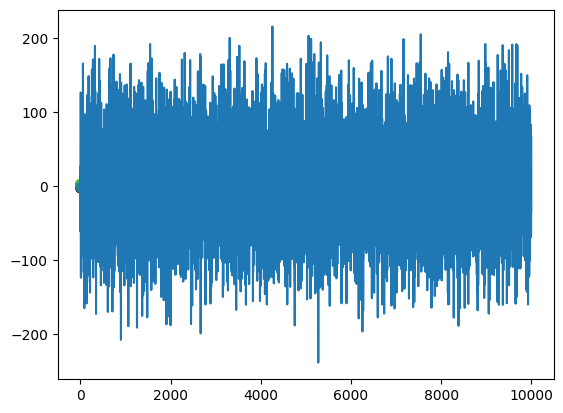

In [134]:
import matplotlib.pyplot as plt

plt.scatter(points[:, 0], points[:, 1], c=dataset[1])
plt.plot(model.predict(dataset[0]))


In [133]:
# 